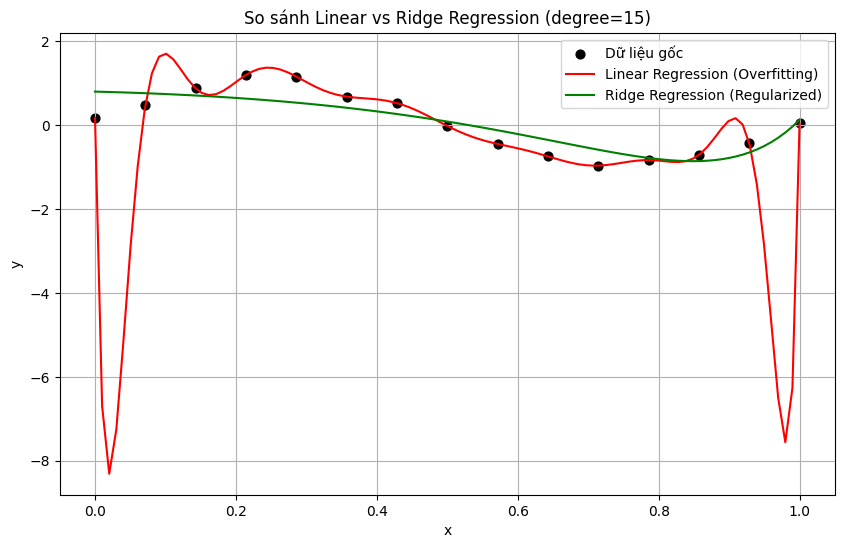

In [ ]:
## Test Ridge Regression vs Linear Regression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

# Tạo dữ liệu đơn giản
np.random.seed(0)
X = np.linspace(0, 1, 15).reshape(-1, 1)
y = np.sin(2 * np.pi * X).ravel() + np.random.randn(15) * 0.1  # Dữ liệu có nhiễu

# Dữ liệu để vẽ đường dự đoán
X_test = np.linspace(0, 1, 100).reshape(-1, 1)

# Hàm tạo pipeline Polynomial Regression
def make_pipeline(model, degree):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

# Linear Regression (không regularization) – dễ overfit
lin_model = make_pipeline(LinearRegression(), degree=15)
lin_model.fit(X, y)
y_pred_lin = lin_model.predict(X_test)

# Ridge Regression – giảm overfitting
ridge_model = make_pipeline(Ridge(alpha=1.0), degree=15)
ridge_model.fit(X, y) # hàm fit giúp học được mean và std nhưng dữ liệu chưa biến đổi 
# phải dùng transform để biến đổi dữ liệu qua điểm Z = x - mean / std
y_pred_ridge = ridge_model.predict(X_test)

# Vẽ kết quả
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label="Dữ liệu gốc", s=40)
plt.plot(X_test, y_pred_lin, label="Linear Regression (Overfitting)", color='red')
plt.plot(X_test, y_pred_ridge, label="Ridge Regression (Regularized)", color='green')
plt.title("So sánh Linear vs Ridge Regression (degree=15)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


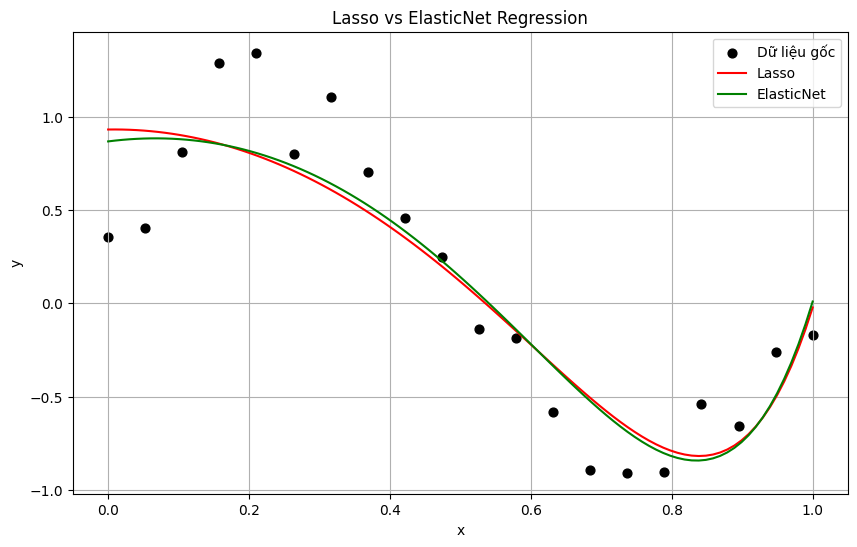

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

# Tạo dữ liệu
np.random.seed(0)
X = np.linspace(0, 1, 20).reshape(-1, 1)
y = np.sin(2 * np.pi * X).ravel() + np.random.randn(20) * 0.2

X_test = np.linspace(0, 1, 100).reshape(-1, 1)

# Hàm tạo pipeline
def make_pipeline(model, degree):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=10)),
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

# Lasso
lasso_model = make_pipeline(Lasso(alpha=0.01, max_iter=10000), degree=10)
lasso_model.fit(X, y)
y_pred_lasso = lasso_model.predict(X_test)

# ElasticNet
elastic_model = make_pipeline(ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000), degree=10)
elastic_model.fit(X, y)
y_pred_elastic = elastic_model.predict(X_test)

# Plot
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='black', label="Dữ liệu gốc", s=40)
plt.plot(X_test, y_pred_lasso, label="Lasso", color='red')
plt.plot(X_test, y_pred_elastic, label="ElasticNet", color='green')
plt.title("Lasso vs ElasticNet Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
